In [148]:
# ===============================
# Data Handling
# ===============================
import pandas as pd
import numpy as np

# ===============================
# Data Visualization
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# Machine Learning / Clustering
# ===============================
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ===============================
# Market Basket Analysis
# ===============================
from mlxtend.frequent_patterns import apriori, association_rules

# ===============================
# Ignore warnings (clean output)
# ===============================
import warnings
warnings.filterwarnings('ignore')

# Task 1: Data Cleaning and Preparation

In [149]:
df = pd.read_csv("Target.csv")

df.describe(include='all')

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
count,800,800.000000,800,800,800,800,800,620,800,800.000000,...,800,800,800,800.000000,800,800.000000,800.000000,800,800,800.000000
unique,460,NaN,4,5,29,3,4,4,2,NaN,...,2,5,3,NaN,3,NaN,NaN,9,18,NaN
top,2023/06/07 2:16:43 PM GMT+5:30,NaN,Male,Multiple times a week,Groceries and Gourmet Food;Beauty and Personal...,No,Multiple times a day,Keyword,First page,NaN,...,Yes,Heavily,No,NaN,Sometimes,NaN,NaN,User-friendly website/app interface,Scrolling option would be much better than goi...,NaN
freq,5,NaN,214,173,37,271,207,173,418,NaN,...,405,170,282,NaN,270,NaN,NaN,105,64,NaN
mean,NaN,34.737500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.003750,...,NaN,NaN,NaN,2.981250,NaN,3.058750,2.935000,NaN,NaN,556455.027500
std,NaN,18.938306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.431362,...,NaN,NaN,NaN,1.450354,NaN,1.439753,1.436438,NaN,NaN,260054.833466
min,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,...,NaN,NaN,NaN,1.000000,NaN,1.000000,1.000000,NaN,NaN,100055.000000
25%,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,...,NaN,NaN,NaN,2.000000,NaN,2.000000,2.000000,NaN,NaN,324800.500000
50%,NaN,34.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,...,NaN,NaN,NaN,3.000000,NaN,3.000000,3.000000,NaN,NaN,565215.500000
75%,NaN,50.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,...,NaN,NaN,NaN,4.000000,NaN,4.000000,4.000000,NaN,NaN,780617.250000


## Remove duplicate or inconsistent survey responses.

In [150]:
df.duplicated().sum()

np.int64(0)

No duplicate rows were found in the dataset (0 duplicates).
Therefore, no rows were removed at this stage.

### What needs fixing 
-Duplicate column :- Personalized_Recommendation_Frequency appears twice . One is object, one is int64
- Wrong data type :- Timestamp is object → should be datetime
- Missing values :- Product_Search_Method → only 620 non-null

In [151]:
# Personalized_Recommendation_Frequency appears twice

# check duplicate columns
df.columns[df.columns.duplicated()]

Index([], dtype='object')

In [152]:
for col in df.columns:
    print(f"'{col}'")

'Timestamp'
'age'
'Gender'
'Purchase_Frequency'
'Purchase_Categories'
'Personalized_Recommendation_Frequency'
'Browsing_Frequency'
'Product_Search_Method'
'Search_Result_Exploration'
'Customer_Reviews_Importance'
'Add_to_Cart_Browsing'
'Cart_Completion_Frequency'
'Cart_Abandonment_Factors'
'Saveforlater_Frequency'
'Review_Left'
'Review_Reliability'
'Review_Helpfulness'
'Personalized_Recommendation_Frequency '
'Recommendation_Helpfulness'
'Rating_Accuracy '
'Shopping_Satisfaction'
'Service_Appreciation'
'Improvement_Areas'
'transaction'


In [153]:
# Step 1 — Remove spaces from column names

df.columns = df.columns.str.strip()

In [154]:
df.columns[df.columns.duplicated()]

Index(['Personalized_Recommendation_Frequency'], dtype='object')

In [155]:
df = df.loc[:, ~df.columns.duplicated()]

In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Timestamp                              800 non-null    object
 1   age                                    800 non-null    int64 
 2   Gender                                 800 non-null    object
 3   Purchase_Frequency                     800 non-null    object
 4   Purchase_Categories                    800 non-null    object
 5   Personalized_Recommendation_Frequency  800 non-null    object
 6   Browsing_Frequency                     800 non-null    object
 7   Product_Search_Method                  620 non-null    object
 8   Search_Result_Exploration              800 non-null    object
 9   Customer_Reviews_Importance            800 non-null    int64 
 10  Add_to_Cart_Browsing                   800 non-null    object
 11  Cart_Completion_Fre

In [157]:
# Fix the Timestamp column

# Right now it’s text (object), but it clearly contains date–time information .

# Convert it:

df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

In [158]:
df['Timestamp'].dtype

datetime64[ns, UTC-05:30]

In [159]:
# Handle missing values (Product_Search_Method)
# From your df.info(): 620 non-null → ~180 missing

df['Product_Search_Method'].isnull().sum()

np.int64(180)

In [160]:
df['Product_Search_Method'].fillna(
    df['Product_Search_Method'].mode()[0],
    inplace=True
)

In [161]:
df['Product_Search_Method'].isnull().sum()

np.int64(0)

In [162]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype                    
---  ------                                 --------------  -----                    
 0   Timestamp                              800 non-null    datetime64[ns, UTC-05:30]
 1   age                                    800 non-null    int64                    
 2   Gender                                 800 non-null    object                   
 3   Purchase_Frequency                     800 non-null    object                   
 4   Purchase_Categories                    800 non-null    object                   
 5   Personalized_Recommendation_Frequency  800 non-null    object                   
 6   Browsing_Frequency                     800 non-null    object                   
 7   Product_Search_Method                  800 non-null    object                   
 8   Search_Result_Exploration     

In [163]:
# Inconsistent survey responses.

## Standardize categorical/numerical entries (e.g., frequency levels, gender, recommendation responses).

In [164]:
# Step 1 — Ensure consistent text format

In [165]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.lower()

In [166]:
for col in df.select_dtypes(include='object').columns:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: Gender
['others' 'male' 'prefer not to say' 'female']

Column: Purchase_Frequency
['once a month' 'multiple times a week' 'few times a month'
 'less than once a month' 'once a week']

Column: Purchase_Categories
['clothing and fashion;others'
 'groceries and gourmet food;beauty and personal care;clothing and fashion;home and kitchen;others'
 'clothing and fashion;home and kitchen'
 'beauty and personal care;clothing and fashion;others'
 'groceries and gourmet food;beauty and personal care;others'
 'beauty and personal care;others'
 'groceries and gourmet food;home and kitchen' 'home and kitchen'
 'beauty and personal care;clothing and fashion;home and kitchen;others'
 'groceries and gourmet food;beauty and personal care'
 'home and kitchen;others'
 'beauty and personal care;home and kitchen;others'
 'groceries and gourmet food;beauty and personal care;clothing and fashion'
 'groceries and gourmet food;clothing and fashion;others' 'others'
 'beauty and personal care;home and ki

In [167]:
# small fixing

In [168]:
# Gender

df['Gender'] = df['Gender'].replace({
    'prefer not to say': 'not_preferred'
})

In [169]:
# Service_Appreciation
df['Service_Appreciation'] = df['Service_Appreciation'].replace({
    '.': 'unknown'
})

In [170]:
# Improvement_Areas
df['Improvement_Areas'] = df['Improvement_Areas'].replace({
    'nil': 'no issues',
    'nothing': 'no issues',
    'no problems with amazon': 'no issues',
    "i don't have any problem with amazon": 'no issues',
    '.': 'unknown',
    'user interface of app': 'user interface',
    'ui': 'user interface'
})

In [171]:
df['Service_Appreciation'].unique()

array(['customer service', 'competitive prices', 'unknown',
       'product recommendations', 'user-friendly website/app interface',
       'wide product selection', 'all the above', 'quick delivery'],
      dtype=object)

In [172]:
df['Improvement_Areas'].unique()

array(['no issues',
       'i have no problem with amazon yet. but others tell me about the refund issues',
       'irrelevant product suggestions',
       'add more familiar brands to the list',
       'product quality and accuracy', 'customer service responsiveness',
       'quality of product is very poor according to the big offers',
       'reducing packaging waste',
       'scrolling option would be much better than going to next page',
       'unknown', 'better app interface and lower shipping charges',
       'user interface', 'shipping speed and reliability'], dtype=object)

In [173]:
df['Gender'].unique()

array(['others', 'male', 'not_preferred', 'female'], dtype=object)

In [174]:
df['Purchase_Frequency'] = df['Purchase_Frequency'].replace({
    'few times a month': 'few times per month',
    'once a week': 'weekly',
    'multiple times a week': 'multiple times per week'
})

In [175]:
# Purchase_Frequency
df['Purchase_Frequency'].unique()

array(['once a month', 'multiple times per week', 'few times per month',
       'less than once a month', 'weekly'], dtype=object)

In [176]:
# Browsing_Frequency
df['Browsing_Frequency'] = df['Browsing_Frequency'].replace({
    'few times a week': 'few times per week',
    'few times a month': 'few times per month'
})

In [177]:
df.select_dtypes(include=['int64', 'float64']).columns

Index(['age', 'Customer_Reviews_Importance', 'Rating_Accuracy',
       'Shopping_Satisfaction', 'transaction'],
      dtype='object')

In [178]:
df.describe()

,age,Customer_Reviews_Importance,Rating_Accuracy,Shopping_Satisfaction,transaction
count,800.000000,800.000000,800.000000,800.000000,800.000000
mean,34.737500,3.003750,3.058750,2.935000,556455.027500
std,18.938306,1.431362,1.439753,1.436438,260054.833466
min,3.000000,1.000000,1.000000,1.000000,100055.000000
25%,18.000000,2.000000,2.000000,2.000000,324800.500000
50%,34.000000,3.000000,3.000000,3.000000,565215.500000
75%,50.250000,4.000000,4.000000,4.000000,780617.250000
max,67.000000,5.000000,5.000000,5.000000,999362.000000


## Handle missing values and inconsistent formats in Product_Search_Method and other fields.

In [179]:
df['Product_Search_Method'].isnull().sum()
df['Product_Search_Method'].unique()

array(['keyword', 'categories', 'others', 'filter'], dtype=object)

In [180]:
df['Product_Search_Method'].isnull().sum()

np.int64(0)

In [181]:
# missing values are already fixed above

## Rename duplicate or misformatted columns (e.g., remove trailing spaces in Rating_Accuracy ).

In [182]:
for col in df.columns:
    print(f"'{col}'")

'Timestamp'
'age'
'Gender'
'Purchase_Frequency'
'Purchase_Categories'
'Personalized_Recommendation_Frequency'
'Browsing_Frequency'
'Product_Search_Method'
'Search_Result_Exploration'
'Customer_Reviews_Importance'
'Add_to_Cart_Browsing'
'Cart_Completion_Frequency'
'Cart_Abandonment_Factors'
'Saveforlater_Frequency'
'Review_Left'
'Review_Reliability'
'Review_Helpfulness'
'Recommendation_Helpfulness'
'Rating_Accuracy'
'Shopping_Satisfaction'
'Service_Appreciation'
'Improvement_Areas'
'transaction'


In [183]:
# it is also fixed above 

## Convert numerical rating columns (e.g., Customer_Reviews_Importance, Shopping_Satisfaction) to appropriate numeric types for analysis

In [184]:
df[['Customer_Reviews_Importance', 'Rating_Accuracy', 'Shopping_Satisfaction']].dtypes

Customer_Reviews_Importance    int64
Rating_Accuracy                int64
Shopping_Satisfaction          int64
dtype: object

In [185]:
# The numerical rating columns were verified and found to be already in appropriate numeric formats (int64), ensuring their suitability for further analysis

### Convert to Clean CSV

In [186]:
clean_df = df.copy()

In [187]:
clean_df.info()
clean_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype                    
---  ------                                 --------------  -----                    
 0   Timestamp                              800 non-null    datetime64[ns, UTC-05:30]
 1   age                                    800 non-null    int64                    
 2   Gender                                 800 non-null    object                   
 3   Purchase_Frequency                     800 non-null    object                   
 4   Purchase_Categories                    800 non-null    object                   
 5   Personalized_Recommendation_Frequency  800 non-null    object                   
 6   Browsing_Frequency                     800 non-null    object                   
 7   Product_Search_Method                  800 non-null    object                   
 8   Search_Result_Exploration     

Timestamp                                0
age                                      0
Gender                                   0
Purchase_Frequency                       0
Purchase_Categories                      0
Personalized_Recommendation_Frequency    0
Browsing_Frequency                       0
Product_Search_Method                    0
Search_Result_Exploration                0
Customer_Reviews_Importance              0
Add_to_Cart_Browsing                     0
Cart_Completion_Frequency                0
Cart_Abandonment_Factors                 0
Saveforlater_Frequency                   0
Review_Left                              0
Review_Reliability                       0
Review_Helpfulness                       0
Recommendation_Helpfulness               0
Rating_Accuracy                          0
Shopping_Satisfaction                    0
Service_Appreciation                     0
Improvement_Areas                        0
transaction                              0
dtype: int6

In [188]:
clean_df.to_csv("cleaned_target_data.csv", index=False)

# Task 2: Descriptive Behavior Analysis

## Summarize customer demographics (age, gender distribution).

In [189]:
# Step 1 — Age Summary (Numerical Overview)

df['age'].describe()

count    800.000000
mean      34.737500
std       18.938306
min        3.000000
25%       18.000000
50%       34.000000
75%       50.250000
max       67.000000
Name: age, dtype: float64

The dataset consists of 800 users with an average age of approximately 35 years, indicating a predominance of young to middle-aged individuals. The age distribution shows a wide range, with most users falling between 18 and 50 years.

In [190]:
# gender distribution
df['Gender'].value_counts()

Gender
male             214
female           201
others           196
not_preferred    189
Name: count, dtype: int64

The gender distribution in the dataset is fairly balanced, with all categories—male, female, others, and not_preferred—having nearly equal representation. This indicates that the dataset does not exhibit any significant gender bias.

## Analyze overall purchase frequency and most popular product categories.

In [191]:
# PART 1 — Purchase Frequency Analysis

In [192]:
# Step 1 — Count purchase frequency

df['Purchase_Frequency'].value_counts()

Purchase_Frequency
multiple times per week    173
less than once a month     168
once a month               164
few times per month        153
weekly                     142
Name: count, dtype: int64

In [193]:
# Step 2 — Convert to percentages
(df['Purchase_Frequency'].value_counts(normalize=True) * 100).round(1)

Purchase_Frequency
multiple times per week    21.6
less than once a month     21.0
once a month               20.5
few times per month        19.1
weekly                     17.8
Name: proportion, dtype: float64

In [194]:
# Step 3 — Visualization (bar chart)

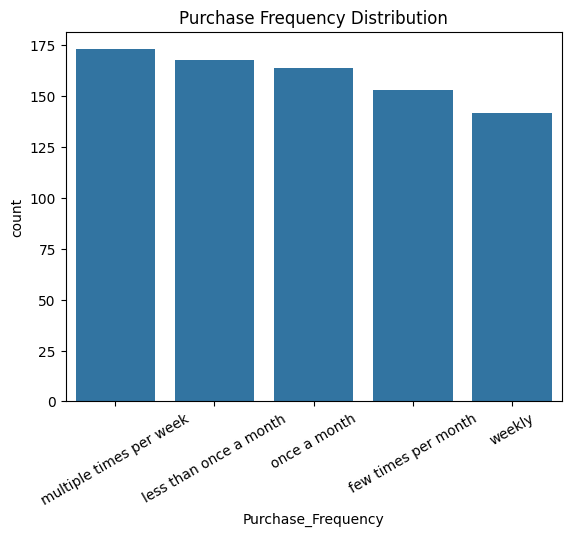

In [195]:
sns.countplot(
    x='Purchase_Frequency',
    data=df,
    order=df['Purchase_Frequency'].value_counts().index
)
plt.xticks(rotation=30)
plt.title("Purchase Frequency Distribution")
plt.show()

The purchase frequency distribution is relatively uniform across all categories, indicating diverse user purchasing behavior. Although ‘multiple times per week’ has the highest frequency, the difference is minimal compared to other categories. This suggests that the platform serves a balanced mix of frequent and occasional shoppers.

In [196]:
# Most Popular Product Categories

In [197]:
# Step 1 — Split the categories
df['Purchase_Categories_Split'] = df['Purchase_Categories'].str.split(';')

In [198]:
# Step 2 — Explode the data
df_exploded = df.explode('Purchase_Categories_Split')

# It converts: Row 1 → 2 rows (one per category)

In [199]:
# Step 3 — Count individual categories
df_exploded['Purchase_Categories_Split'].value_counts()

Purchase_Categories_Split
beauty and personal care      426
clothing and fashion          424
home and kitchen              406
groceries and gourmet food    403
others                        384
Name: count, dtype: int64

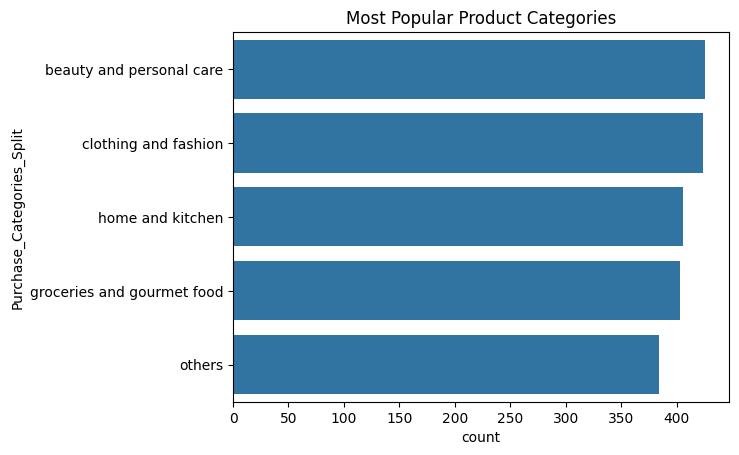

In [200]:
# Step 4 — Visualization

sns.countplot(
    y='Purchase_Categories_Split',
    data=df_exploded,
    order=df_exploded['Purchase_Categories_Split'].value_counts().index
)

plt.title("Most Popular Product Categories")
plt.show()

Analysis of product categories shows that beauty and personal care is the most popular category, closely followed by clothing and fashion, home and kitchen, and groceries and gourmet food. The differences in counts across categories are minimal, indicating that user preferences are evenly distributed across multiple product types. This suggests that customers engage in cross-category purchasing behavior and are interested in a wide range of lifestyle and essential products.

## Identify top browsing methods and most common cart abandonment factors.

In [201]:
# PART 1 — Top Browsing Methods

In [202]:
#Step 1 — Count browsing/search methods
df['Product_Search_Method'].value_counts()

Product_Search_Method
keyword       353
others        158
filter        157
categories    132
Name: count, dtype: int64

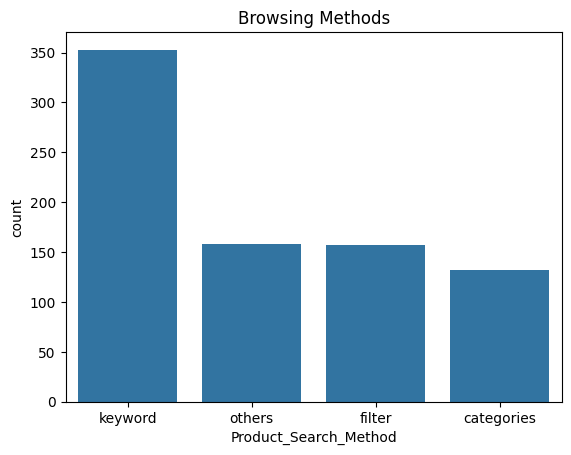

In [203]:
# Step 2 - Visualization
sns.countplot(x='Product_Search_Method', data=df,
              order=df['Product_Search_Method'].value_counts().index)
plt.title("Browsing Methods")
plt.show()

Analysis of browsing behavior shows that keyword-based search is the most commonly used method, accounting for a significant portion of user interactions. This indicates that users prefer directly searching for specific products rather than browsing through categories. Filtering and other methods are moderately used, while category-based browsing is the least preferred approach, suggesting limited exploratory behavior among users.

In [204]:
# PART 2 — Cart Abandonment Factors

In [205]:
# Step 3 — Count abandonment reasons
df['Cart_Abandonment_Factors'].value_counts()

Cart_Abandonment_Factors
high shipping costs                           216
others                                        203
changed my mind or no longer need the item    191
found a better price elsewhere                190
Name: count, dtype: int64

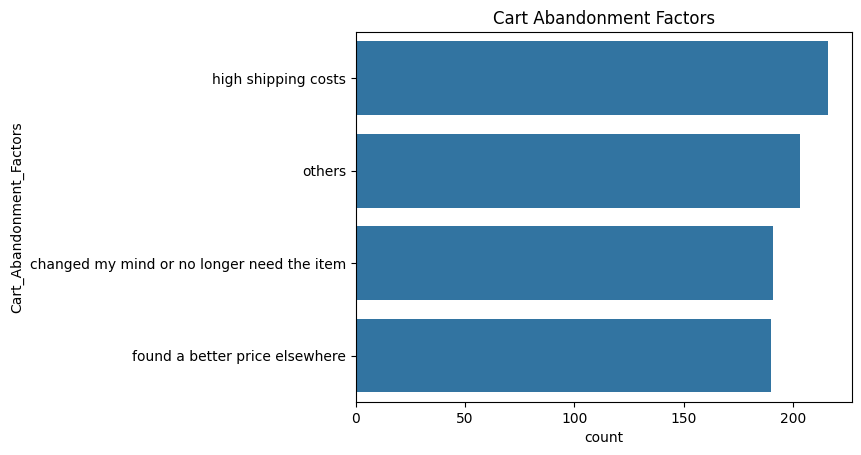

In [206]:
# Step 4 — Visualization
sns.countplot(
    y='Cart_Abandonment_Factors',
    data=df,
    order=df['Cart_Abandonment_Factors'].value_counts().index
)
plt.title("Cart Abandonment Factors")
plt.show()

Analysis of cart abandonment factors reveals that high shipping costs are the most significant reason for users not completing purchases. This indicates strong price sensitivity among customers, particularly regarding additional costs. Other factors such as finding better prices elsewhere and changes in user intent also contribute significantly, suggesting that cart abandonment is influenced by both competitive pricing and user decision behavior. Overall, the distribution of factors indicates that no single issue dominates, highlighting the need for a multi-faceted approach to reduce cart abandonment.

## Calculate mean and median satisfaction, recommendation helpfulness, and rating accuracy.

In [207]:
# Step 1 — Convert to numeric 
mapping = {
    'no': 1,
    'sometimes': 2,
    'yes': 3
}

df['Recommendation_Helpfulness'] = df['Recommendation_Helpfulness'].map(mapping)

In [208]:
# Step 2 — Calculate mean
df[['Shopping_Satisfaction',
    'Recommendation_Helpfulness',
    'Rating_Accuracy']].mean()

Shopping_Satisfaction         2.93500
Recommendation_Helpfulness    2.00000
Rating_Accuracy               3.05875
dtype: float64

In [209]:
df[['Shopping_Satisfaction',
    'Recommendation_Helpfulness',
    'Rating_Accuracy']].median()

Shopping_Satisfaction         3.0
Recommendation_Helpfulness    2.0
Rating_Accuracy               3.0
dtype: float64

The median values of shopping satisfaction and rating accuracy are both 3, indicating that the typical user perceives these aspects at a moderate level. In contrast, the median value of recommendation helpfulness is 2, suggesting that most users find recommendations less helpful. The close alignment between mean and median values across all metrics indicates a balanced distribution of responses, with no significant skewness. Overall, users exhibit moderate satisfaction and trust in ratings, but relatively lower confidence in recommendation systems

## Generate summary statistics and visualizations for key behavioral variables.

In [210]:
# Step 2 — Generate summary statistics
# For numerical variables
df[['Shopping_Satisfaction',
    'Recommendation_Helpfulness',
    'Rating_Accuracy']].describe()

,Shopping_Satisfaction,Recommendation_Helpfulness,Rating_Accuracy
count,800.000000,800.00000,800.000000
mean,2.935000,2.00000,3.058750
std,1.436438,0.81445,1.439753
min,1.000000,1.00000,1.000000
25%,2.000000,1.00000,2.000000
50%,3.000000,2.00000,3.000000
75%,4.000000,3.00000,4.000000
max,5.000000,3.00000,5.000000


In [211]:
# For categorical variables
df['Purchase_Frequency'].value_counts()

Purchase_Frequency
multiple times per week    173
less than once a month     168
once a month               164
few times per month        153
weekly                     142
Name: count, dtype: int64

In [212]:
df['Browsing_Frequency'].value_counts()

Browsing_Frequency
multiple times a day    207
rarely                  200
few times per month     197
few times per week      196
Name: count, dtype: int64

In [213]:
df['Cart_Completion_Frequency'].value_counts()

Cart_Completion_Frequency
rarely       180
sometimes    160
always       159
often        158
never        143
Name: count, dtype: int64

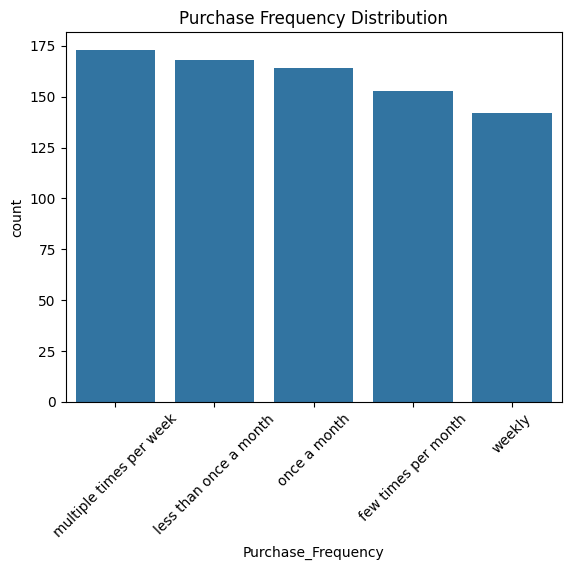

In [214]:
# 1. Purchase Frequency
sns.countplot(x='Purchase_Frequency', data=df,
              order=df['Purchase_Frequency'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Purchase Frequency Distribution")
plt.show()

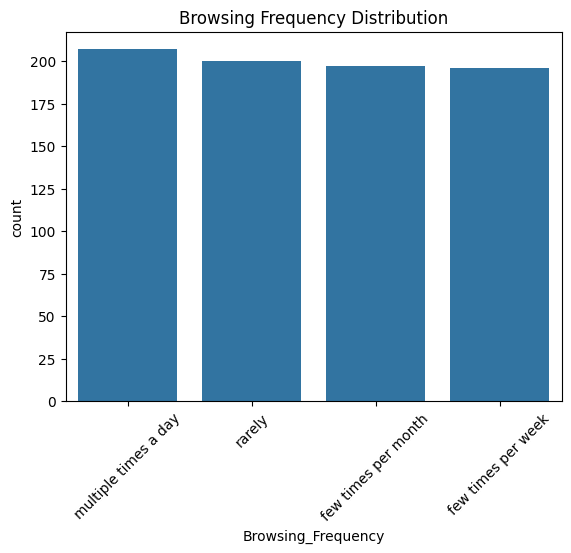

In [215]:
# 2. Browsing Frequency
sns.countplot(x='Browsing_Frequency', data=df,
              order=df['Browsing_Frequency'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Browsing Frequency Distribution")
plt.show()

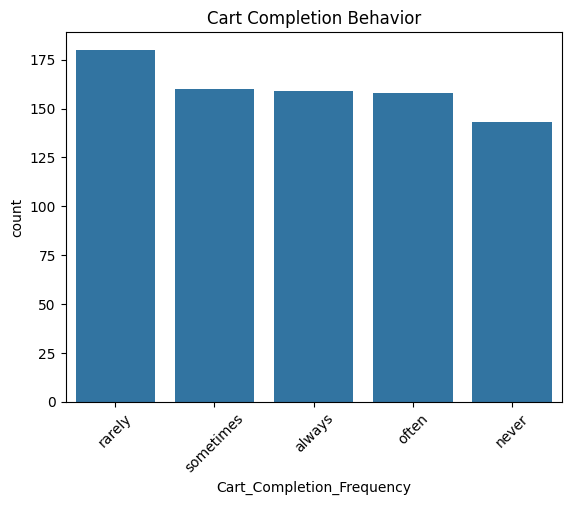

In [216]:
# 3. Cart Completion
sns.countplot(x='Cart_Completion_Frequency', data=df,
              order=df['Cart_Completion_Frequency'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Cart Completion Behavior")
plt.show()

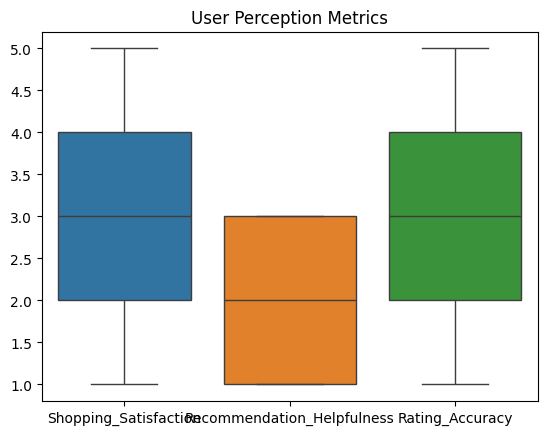

In [217]:
# 4. Satisfaction & Ratings (Boxplot)
sns.boxplot(data=df[['Shopping_Satisfaction',
                     'Recommendation_Helpfulness',
                     'Rating_Accuracy']])
plt.title("User Perception Metrics")
plt.show()

Summary statistics and visualizations of key behavioral variables reveal that user behavior is diverse across multiple dimensions. Purchase frequency is evenly distributed, indicating a mix of frequent and occasional shoppers. Browsing frequency also shows a balanced pattern, suggesting consistent engagement among users.

Cart completion behavior highlights a tendency toward incomplete purchases, with many users reporting that they rarely complete transactions, indicating potential issues in the purchase journey.

User perception metrics show moderate satisfaction and trust levels, with rating accuracy being relatively well-regarded. However, recommendation helpfulness scores are lower, suggesting that the recommendation system may require improvement. Overall, the analysis indicates a balanced user base with opportunities to enhance conversion rates and recommendation effectiveness.

# Task 3: Customer Segmentation and Profiling 

In [218]:
# some changes need to be made in required columns for clustering

In [219]:
# Recommendation_Helpfulness

In [220]:
df['Recommendation_Helpfulness'].unique()

array([2, 3, 1])

In [221]:
df['Recommendation_Helpfulness'].dtype

dtype('int64')

In [222]:
df['Recommendation_Helpfulness'].isnull().sum()

np.int64(0)

In [223]:
# Purchase_Frequency

In [224]:
df['Purchase_Frequency'].unique()

array(['once a month', 'multiple times per week', 'few times per month',
       'less than once a month', 'weekly'], dtype=object)

In [225]:
purchase_map = {
    'less than once a month': 1,
    'once a month': 2,
    'few times per month': 3,
    'weekly': 4,
    'multiple times per week': 5
}

In [226]:
df['Purchase_Frequency'] = df['Purchase_Frequency'].map(purchase_map)

In [227]:
df['Purchase_Frequency'].dtype

dtype('int64')

In [228]:
df['Recommendation_Helpfulness'].isnull().sum()

np.int64(0)

In [229]:
# 2. Browsing_Frequency
df['Browsing_Frequency'].unique()

array(['rarely', 'few times per month', 'multiple times a day',
       'few times per week'], dtype=object)

In [230]:
browsing_map = {
    'rarely': 1,
    'few times per month': 2,
    'few times per week': 3,
    'multiple times a day': 4
}

df['Browsing_Frequency'] = df['Browsing_Frequency'].map(browsing_map)

In [231]:
df['Browsing_Frequency'].dtype

dtype('int64')

In [232]:
df['Browsing_Frequency'].isnull().sum()

np.int64(0)

In [233]:
# 3. Cart_Completion_Frequency
df['Cart_Completion_Frequency'].unique()

array(['rarely', 'always', 'sometimes', 'often', 'never'], dtype=object)

In [234]:
cart_map = {
    'never': 1,
    'rarely': 2,
    'sometimes': 3,
    'often': 4,
    'always': 5
}

df['Cart_Completion_Frequency'] = df['Cart_Completion_Frequency'].map(cart_map)

In [235]:
df['Cart_Completion_Frequency'].isnull().sum()

np.int64(0)

In [236]:
# 4. Add_to_Cart_Browsing
df['Add_to_Cart_Browsing'].unique()

array(['maybe', 'no', 'yes'], dtype=object)

In [237]:
add_cart_map = {
    'no': 1,
    'maybe': 2,
    'yes': 3
}

df['Add_to_Cart_Browsing'] = df['Add_to_Cart_Browsing'].map(add_cart_map)

In [238]:
df['Add_to_Cart_Browsing'].isnull().sum()

np.int64(0)

In [239]:
features = [
    'Purchase_Frequency',
    'Browsing_Frequency',
    'Cart_Completion_Frequency',
    'Add_to_Cart_Browsing',
    'Shopping_Satisfaction',
    'Recommendation_Helpfulness',
    'Rating_Accuracy'
]

In [240]:
df[features].head()

,Purchase_Frequency,Browsing_Frequency,Cart_Completion_Frequency,Add_to_Cart_Browsing,Shopping_Satisfaction,Recommendation_Helpfulness,Rating_Accuracy
0,2,1,2,2,1,2,2
1,5,2,2,1,3,2,5
2,3,4,5,1,2,3,3
3,5,4,3,3,4,2,1
4,5,2,4,3,5,1,2


## Segment customers based on purchase frequency and shopping satisfaction levels.

Define “Low / Medium / High” 
-----------------------------
We convert numbers into levels.

Purchase Frequency
-----------------
Value	Level
-----   -----
1–2	    Low
3	    Medium
4–5 	High


Satisfaction
------------
Value	Level
-----   -----
1–2	    Low
3	    Medium
4–5	    High

In [241]:
# Step 3 — logic of segmentation
def segment_customer(row):
    freq = row['Purchase_Frequency']
    sat = row['Shopping_Satisfaction']
    
    # Frequent Buyers
    if freq >= 4 and sat >= 4:
        return "Frequent Buyers"
    
    # At-Risk Customers
    elif freq <= 2 or sat <= 2:
        return "At-Risk Customers"
    
    # Occasional Shoppers
    else:
        return "Occasional Shoppers"

In [242]:
# Step 4 — Apply segmentation
df['Customer_Segment'] = df.apply(segment_customer, axis=1)

In [243]:
df['Customer_Segment'].value_counts()

Customer_Segment
At-Risk Customers      534
Occasional Shoppers    154
Frequent Buyers        112
Name: count, dtype: int64

In [244]:
df[['Purchase_Frequency', 'Shopping_Satisfaction', 'Customer_Segment']].head(10)

,Purchase_Frequency,Shopping_Satisfaction,Customer_Segment
0,2,1,At-Risk Customers
1,5,3,Occasional Shoppers
2,3,2,At-Risk Customers
3,5,4,Frequent Buyers
4,5,5,Frequent Buyers
5,1,3,At-Risk Customers
6,3,1,At-Risk Customers
7,5,4,Frequent Buyers
8,5,3,Occasional Shoppers
9,4,5,Frequent Buyers


Customer segmentation reveals that a majority of users fall into the At-Risk category, indicating low engagement or satisfaction levels among a large portion of the customer base. In contrast, Frequent Buyers form a relatively small segment, highlighting limited highly engaged users. Occasional Shoppers represent a moderate group. This skewed distribution suggests the need for targeted interventions to improve customer satisfaction and retention.

## Create profiles such as:
○ Frequent Buyers: High purchase frequency, high satisfaction.
○ Occasional Shoppers: Medium frequency, moderate satisfaction.
○ At-Risk Customers: Low satisfaction or frequent cart abandonment

In [245]:
# Step 1 — Check how many users in each segment
df['Customer_Segment'].value_counts()

Customer_Segment
At-Risk Customers      534
Occasional Shoppers    154
Frequent Buyers        112
Name: count, dtype: int64

In [246]:
# Step 2 — Compare average behavior across segments
df.groupby('Customer_Segment')[[
    'Purchase_Frequency',
    'Shopping_Satisfaction',
    'Cart_Completion_Frequency',
    'Browsing_Frequency'
]].mean()

,Purchase_Frequency,Shopping_Satisfaction,Cart_Completion_Frequency,Browsing_Frequency
Customer_Segment,,,,
At-Risk Customers,2.458801,2.413858,3.050562,2.529963
Frequent Buyers,4.535714,4.544643,3.160714,2.517857
Occasional Shoppers,3.681818,3.571429,2.772727,2.448052


In [247]:
# Step 3 — Look at cart behavior (important for At-Risk)
df.groupby('Customer_Segment')['Cart_Completion_Frequency'].mean()

Customer_Segment
At-Risk Customers      3.050562
Frequent Buyers        3.160714
Occasional Shoppers    2.772727
Name: Cart_Completion_Frequency, dtype: float64

###Build profiles 
---------------
1. Frequent Buyers (High Value Customers)
-----------------------------------------
Frequent Buyers exhibit high purchase frequency (≈4.5) and high satisfaction levels (≈4.5), indicating strong engagement and loyalty toward the platform. They also show slightly higher cart completion behavior, suggesting efficient decision-making and lower hesitation during purchases. These customers represent the most valuable segment and are likely to contribute significantly to revenue.”

2. Occasional Shoppers (Moderate Engagement Group)
---------------------------------------------------
Occasional Shoppers demonstrate moderate purchase frequency (≈3.7) and satisfaction (≈3.6), indicating balanced but not highly committed behavior. Their relatively lower cart completion frequency suggests some hesitation in finalizing purchases. This group represents an opportunity for growth, as targeted strategies such as personalized recommendations and promotions could convert them into frequent buyers.”

3. At-Risk Customers (Low Engagement Group)
---------------------------------------------
At-Risk Customers have low purchase frequency (≈2.5) and low satisfaction (≈2.4), indicating disengagement from the platform. Although their cart completion behavior is moderate, their lower satisfaction suggests dissatisfaction . This segment requires immediate attention, as these users are more likely to reduce activity or churn.

## Analyze demographic or behavioral differences across these segments.

In [248]:
#Step 1 — Compare behavioral variables

df.groupby('Customer_Segment')[[
    'Purchase_Frequency',
    'Shopping_Satisfaction',
    'Cart_Completion_Frequency',
    'Browsing_Frequency'
]].mean()

,Purchase_Frequency,Shopping_Satisfaction,Cart_Completion_Frequency,Browsing_Frequency
Customer_Segment,,,,
At-Risk Customers,2.458801,2.413858,3.050562,2.529963
Frequent Buyers,4.535714,4.544643,3.160714,2.517857
Occasional Shoppers,3.681818,3.571429,2.772727,2.448052


###Step 2 — Interpret behavioral differences
-----------------------------------------

Insight 1 — Clear separation in engagement
------------------------------------------
Frequent Buyers exhibit significantly higher purchase frequency and satisfaction compared to other segments, indicating strong engagement and loyalty.

Insight 2 — At-Risk customers are disengaged
--------------------------------------------
At-Risk Customers show the lowest purchase frequency and satisfaction, reflecting disengagement and potential dissatisfaction with the platform.

Insight 3 — Occasional Shoppers are transitional
-------------------------------------------------
Occasional Shoppers fall between the two extremes, with moderate purchase frequency and satisfaction, suggesting they are neither highly engaged nor completely disengaged.

Insight 4 — Cart behavior difference
-------------------------------------
Cart completion is highest among Frequent Buyers and lowest among Occasional Shoppers, indicating that hesitation during purchase is more prominent in the latter group.

In [249]:
# Step 3 — Compare demographic variables

In [250]:
# Age
df.groupby('Customer_Segment')['age'].mean()

Customer_Segment
At-Risk Customers      34.086142
Frequent Buyers        35.892857
Occasional Shoppers    36.155844
Name: age, dtype: float64

 There is minimal variation in average age across segments, suggesting that age does not significantly influence customer behavior.

In [251]:
# Gender
df.groupby('Customer_Segment')['Gender'].value_counts()

Customer_Segment     Gender       
At-Risk Customers    not_preferred    144
                     female           140
                     male             138
                     others           112
Frequent Buyers      male              35
                     others            34
                     female            26
                     not_preferred     17
Occasional Shoppers  others            50
                     male              41
                     female            35
                     not_preferred     28
Name: count, dtype: int64

The gender distribution across all customer segments is relatively balanced, with no single gender category dominating any segment. This indicates that customer behavior and engagement levels are not significantly influenced by gender.

## Use clustering (e.g., K-Means) for behavioral grouping based on survey responses.

### Goal of Clustering :-
-------------------
Instead of manually creating segments, we let the algorithm:

Automatically group similar customers based on behavior

In [252]:
# Step 1 — Select features for clustering

features = [
    'Purchase_Frequency',
    'Browsing_Frequency',
    'Cart_Completion_Frequency',
    'Shopping_Satisfaction',
    'Recommendation_Helpfulness',
    'Rating_Accuracy'
]

X = df[features]
# We only take behavior-related columns

In [253]:
# Step 2 — Scale the data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Different columns have different ranges:

Satisfaction (1–5)
Frequency (1–5)

Scaling ensures all features contribute equally

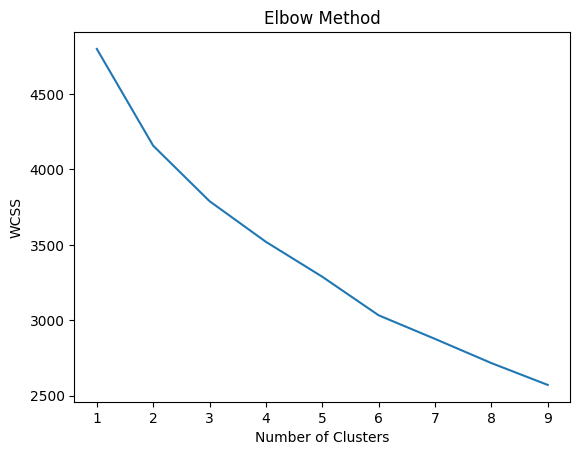

In [254]:
# Step 3 — Find optimal number of clusters
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [255]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [256]:
df['Cluster'].value_counts()

Cluster
1    320
0    258
2    222
Name: count, dtype: int64

In [257]:
df.groupby('Cluster')[features].mean()

,Purchase_Frequency,Browsing_Frequency,Cart_Completion_Frequency,Shopping_Satisfaction,Recommendation_Helpfulness,Rating_Accuracy
Cluster,,,,,,
0,3.077519,1.903101,3.399225,2.751938,1.763566,1.666667
1,2.743750,3.525000,2.821875,3.128125,2.340625,3.287500
2,3.225225,1.761261,2.837838,2.869369,1.783784,4.346847


##### 

In [258]:
cluster_map = {
    0: "At-Risk Customers",
    1: "Occasional Shoppers",
    2: "Frequent / Engaged Users"
}

df['Cluster_Label'] = df['Cluster'].map(cluster_map)

In [259]:
df.groupby('Cluster_Label')[features].mean()

,Purchase_Frequency,Browsing_Frequency,Cart_Completion_Frequency,Shopping_Satisfaction,Recommendation_Helpfulness,Rating_Accuracy
Cluster_Label,,,,,,
At-Risk Customers,3.077519,1.903101,3.399225,2.751938,1.763566,1.666667
Frequent / Engaged Users,3.225225,1.761261,2.837838,2.869369,1.783784,4.346847
Occasional Shoppers,2.743750,3.525000,2.821875,3.128125,2.340625,3.287500


In [260]:
pd.crosstab(df['Customer_Segment'], df['Cluster_Label'])

Cluster_Label,At-Risk Customers,Frequent / Engaged Users,Occasional Shoppers
Customer_Segment,,,
At-Risk Customers,179,138,217
Frequent Buyers,37,35,40
Occasional Shoppers,42,49,63


### Insight
-------
K-Means clustering was applied to group customers based on behavioral attributes such as purchase frequency, browsing behavior, satisfaction, and recommendation perception. The Elbow Method indicated that k = 3 is the optimal number of clusters.

The resulting clusters revealed distinct behavioral patterns: one group exhibited low satisfaction and trust, representing at-risk customers; another group showed high browsing but moderate purchasing behavior, indicating occasional or exploratory users; and a third group demonstrated relatively higher engagement and trust in ratings, representing more active users.

Comparison with manually defined segments shows partial alignment, validating the segmentation approach while also highlighting nuanced differences captured by the clustering algorithm.

# Task 4: Recommendation and Review Insights

## Examine the relationship between recommendation helpfulness and shopping satisfaction.

In [261]:
df['Recommendation_Helpfulness'].dtype
df['Recommendation_Helpfulness'].unique()

array([2, 3, 1])

In [262]:
# Step 1 — Group and calculate
df.groupby('Recommendation_Helpfulness')['Shopping_Satisfaction'].mean()

Recommendation_Helpfulness
1    2.875472
2    2.977778
3    2.950943
Name: Shopping_Satisfaction, dtype: float64

In [263]:
# Step 2 — Check correlation
df[['Recommendation_Helpfulness', 'Shopping_Satisfaction']].corr()

,Recommendation_Helpfulness,Shopping_Satisfaction
Recommendation_Helpfulness,1.000000,0.021396
Shopping_Satisfaction,0.021396,1.000000


The relationship between recommendation helpfulness and shopping satisfaction is extremely weak, as indicated by a correlation value close to zero (0.02). Group-wise analysis also shows minimal variation in satisfaction across different levels of recommendation helpfulness. This suggests that recommendation systems do not significantly influence overall customer satisfaction in this dataset. Therefore, other factors such as product quality, pricing, and delivery efficiency are likely to play a more critical role in shaping customer satisfaction.

## Evaluate how review reliability and helpfulness impact overall ratings.

In [264]:
df['Review_Reliability'].unique()

array(['heavily', 'occasionally', 'rarely', 'never', 'moderately'],
      dtype=object)

In [265]:
df['Review_Helpfulness'].unique()

array(['yes', 'sometimes', 'no'], dtype=object)

In [266]:
# Convert Review_Reliability
reliability_map = {
    'never': 1,
    'rarely': 2,
    'occasionally': 3,
    'moderately': 4,
    'heavily': 5
}

df['Review_Reliability'] = df['Review_Reliability'].map(reliability_map)

In [267]:
# Convert Review_Helpfulness
helpfulness_map = {
    'no': 1,
    'sometimes': 2,
    'yes': 3
}

df['Review_Helpfulness'] = df['Review_Helpfulness'].map(helpfulness_map)

In [268]:
# Step 2 — Group analysis

In [269]:
# Review Reliability vs Rating Accuracy
df.groupby('Review_Reliability')['Rating_Accuracy'].mean()

Review_Reliability
1    3.085890
2    3.139394
3    3.040000
4    2.940789
5    3.076471
Name: Rating_Accuracy, dtype: float64

In [270]:
# Review Helpfulness vs Rating Accuracy
df.groupby('Review_Helpfulness')['Rating_Accuracy'].mean()

Review_Helpfulness
1    3.131206
2    2.992565
3    3.048193
Name: Rating_Accuracy, dtype: float64

In [271]:
# Step 3 — Correlation analysis

In [272]:
# Reliability correlation
df[['Review_Reliability', 'Rating_Accuracy']].corr()

,Review_Reliability,Rating_Accuracy
Review_Reliability,1.000000,-0.020609
Rating_Accuracy,-0.020609,1.000000


In [273]:
# Helpfulness correlation
df[['Review_Helpfulness', 'Rating_Accuracy']].corr()

,Review_Helpfulness,Rating_Accuracy
Review_Helpfulness,1.000000,-0.024622
Rating_Accuracy,-0.024622,1.000000


In [274]:
# Step 4 — Visualization

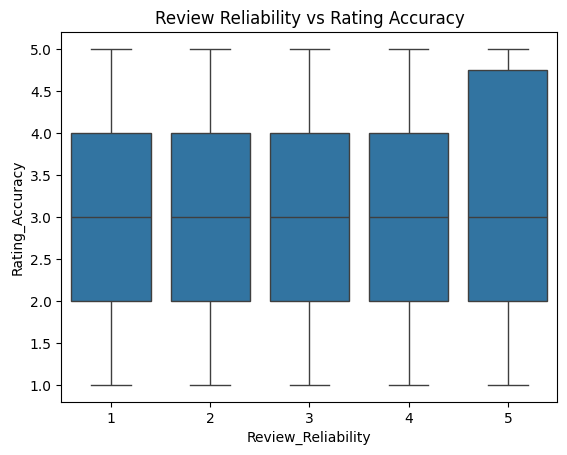

In [275]:
# Reliability plot

sns.boxplot(
    x='Review_Reliability',
    y='Rating_Accuracy',
    data=df
)

plt.title("Review Reliability vs Rating Accuracy")
plt.show()

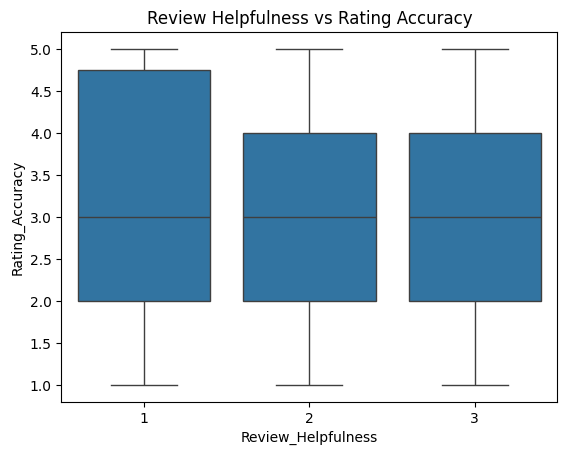

In [276]:
# Helpfulness plot
sns.boxplot(
    x='Review_Helpfulness',
    y='Rating_Accuracy',
    data=df
)

plt.title("Review Helpfulness vs Rating Accuracy")
plt.show()

Insight
---------
The analysis indicates that both review reliability and review helpfulness have a negligible impact on rating accuracy. Group-wise comparisons show minimal variation in rating accuracy across different levels of review reliability and helpfulness. Correlation values close to zero further confirm the absence of a significant relationship. Additionally, boxplot visualizations reveal consistent median values and overlapping distributions, indicating that changes in perceived review quality do not meaningfully influence how users rate products.

## Identify trends in how often customers engage with or trust personalized recommendations.

In [277]:
# Convert frequency to numeric
df['Personalized_Recommendation_Frequency'].unique()

array(['no', 'yes', 'sometimes'], dtype=object)

In [278]:
freq_map = {
    'no': 1,
    'sometimes': 2,
    'yes': 3
}

df['Personalized_Recommendation_Frequency'] = df['Personalized_Recommendation_Frequency'].map(freq_map)

In [279]:
# Step 3 — Distribution (engagement level)
df['Personalized_Recommendation_Frequency'].value_counts()

Personalized_Recommendation_Frequency
1    271
3    271
2    258
Name: count, dtype: int64

In [280]:
# Step 4 — Trust analysis (helpfulness distribution)
df['Recommendation_Helpfulness'].value_counts()

Recommendation_Helpfulness
2    270
3    265
1    265
Name: count, dtype: int64

In [281]:
# Step 5 — Relationship between engagement & trust
df.groupby('Personalized_Recommendation_Frequency')['Recommendation_Helpfulness'].mean()

Personalized_Recommendation_Frequency
1    1.996310
2    2.015504
3    1.988930
Name: Recommendation_Helpfulness, dtype: float64

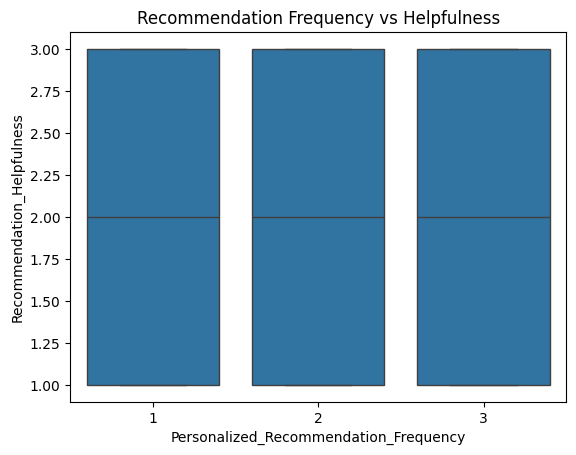

In [282]:
# Step 6 — Visualization
sns.boxplot(
    x='Personalized_Recommendation_Frequency',
    y='Recommendation_Helpfulness',
    data=df
)

plt.title("Recommendation Frequency vs Helpfulness")
plt.show()

The analysis shows that customer engagement with personalized recommendations is evenly distributed across low, medium, and high frequency levels. Similarly, the perceived helpfulness of recommendations is also balanced, with most users rating them as moderately useful. However, the relationship between recommendation frequency and helpfulness is weak, as the average helpfulness remains nearly constant across all frequency levels. This indicates that increasing the number of recommendations does not significantly improve user trust or perceived usefulness.

## Suggest actionable insights for improving Target’s recommendation system.

In [298]:
# Step 1 — Prepare the data
df['Purchase_Categories_List'] = df['Purchase_Categories'].str.split(';')

In [299]:
# Step 2 — Convert into transaction format
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_data = te.fit(df['Purchase_Categories_List']).transform(df['Purchase_Categories_List'])

df_encoded = pd.DataFrame(te_data, columns=te.columns_)

In [300]:
# Step 3 — Apply Apriori Algorithm
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(df_encoded, min_support=0.1, use_colnames=True)

In [301]:
# Step 4 — Generate association rules
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

In [302]:
# Step 5 — View rules
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

,antecedents,consequents,support,confidence,lift
0,(beauty and personal care),(clothing and fashion),0.27250,0.511737,0.965542
1,(clothing and fashion),(beauty and personal care),0.27250,0.514151,0.965542
2,(groceries and gourmet food),(beauty and personal care),0.25875,0.513648,0.964597
3,(beauty and personal care),(groceries and gourmet food),0.25875,0.485915,0.964597
4,(home and kitchen),(beauty and personal care),0.24750,0.487685,0.915840
5,(beauty and personal care),(home and kitchen),0.24750,0.464789,0.915840
6,(others),(beauty and personal care),0.24875,0.518229,0.973200
7,(beauty and personal care),(others),0.24875,0.467136,0.973200
8,(groceries and gourmet food),(clothing and fashion),0.27625,0.548387,1.034693
9,(clothing and fashion),(groceries and gourmet food),0.27625,0.521226,1.034693


Convert into system-level recommendations
-----------------------------------------
1. Smart Cross-Selling

“When users add groceries or home products to cart, dynamically recommend clothing items.”

2. Cart Page Recommendations

“Display ‘You may also like clothing items’ based on multi-category purchases.”

3. Bundle Creation

“Create bundles such as:

Home + Grocery + Clothing
Beauty + Home + Clothing”

4. Personalized Recommendation Engine

“Use Apriori rules to trigger real-time recommendations based on current user behavior.”

5. Priority-Based Recommendations

Rank recommendations by:

highest lift
highest confidence

Final Answer 
-------------
The Apriori analysis revealed several strong association rules between product categories. Notably, customers purchasing combinations of groceries, home, and miscellaneous items show a high likelihood of purchasing clothing products, with lift values exceeding 1, indicating strong relationships. These insights suggest that clothing products serve as a key cross-selling category. Based on these findings, the recommendation system can be enhanced by suggesting clothing items to users engaged in related categories, implementing bundle offers, and displaying dynamic ‘frequently bought together’ suggestions. Leveraging these data-driven rules can significantly improve recommendation relevance and increase conversion rates.

# Task 5: Visualization and Reporting 

## Create attractive visualizations (bar charts, heatmaps, pie charts) for:
1 Purchase categories
2 Browsing frequency distribution
3 Satisfaction levels
4 Correlation between recommendation usefulness and satisfaction

In [283]:
# Step 1 — Purchase Categories (Bar Chart) 

In [284]:
df_exploded = df.explode('Purchase_Categories_Split')

In [285]:
category_counts = df_exploded['Purchase_Categories_Split'].value_counts()

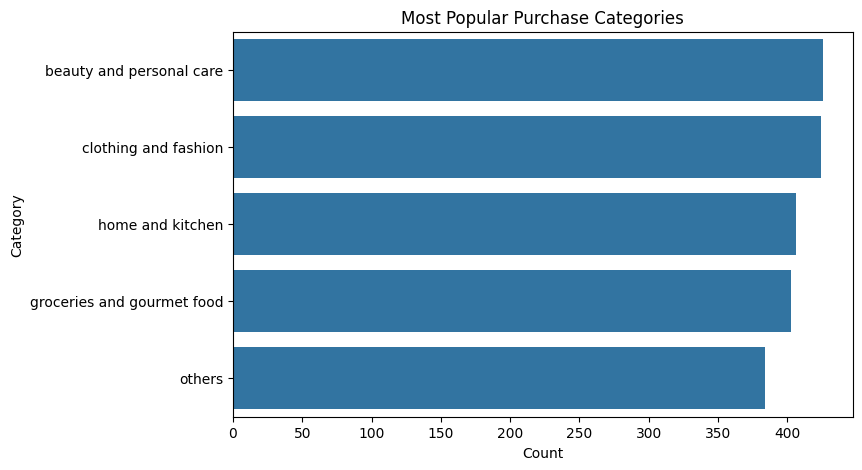

In [286]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title("Most Popular Purchase Categories")
plt.xlabel("Count")
plt.ylabel("Category")

plt.show()

The bar chart of purchase categories shows that certain product categories are significantly more popular than others. Categories such as beauty and personal care and clothing and fashion appear more frequently, indicating higher customer preference. Less frequent categories represent niche or less demanded product segments.

In [287]:
# Step 2 — Browsing Frequency Distribution (Bar Chart)

In [288]:
df['Browsing_Frequency'].value_counts()

Browsing_Frequency
4    207
1    200
2    197
3    196
Name: count, dtype: int64

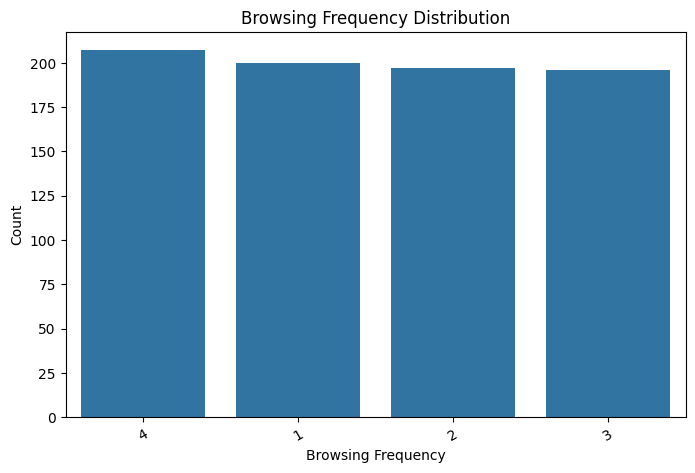

In [289]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Browsing_Frequency',
    data=df,
    order=df['Browsing_Frequency'].value_counts().index
)

plt.title("Browsing Frequency Distribution")
plt.xlabel("Browsing Frequency")
plt.ylabel("Count")

plt.xticks(rotation=30)
plt.show()

The browsing frequency distribution shows that a significant portion of users engage with the platform frequently, with many users browsing multiple times a day or several times a week. This indicates a relatively high level of user activity. However, the presence of users who browse rarely suggests that there is still a segment with lower engagement that could be targeted for improvement.

In [290]:
# Step 3 — Satisfaction Levels

In [291]:
df['Shopping_Satisfaction'].value_counts()

Shopping_Satisfaction
1    173
2    167
5    166
3    165
4    129
Name: count, dtype: int64

In [292]:
satisfaction_counts = df['Shopping_Satisfaction'].value_counts().sort_index()

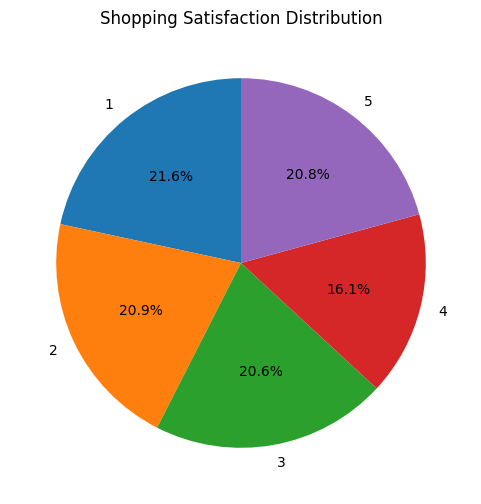

In [293]:
plt.figure(figsize=(6,6))

plt.pie(
    satisfaction_counts,
    labels=satisfaction_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Shopping Satisfaction Distribution")

plt.show()

The pie chart of shopping satisfaction shows that the majority of users fall within the mid-level satisfaction range, particularly around level 3. This indicates that most customers are moderately satisfied with their shopping experience. A smaller proportion of users report high satisfaction levels, while a notable segment reflects lower satisfaction. This distribution suggests that there is significant scope for improving overall customer satisfaction.

In [294]:
# Step 4 — Correlation Heatmap

In [295]:
df[['Recommendation_Helpfulness', 'Shopping_Satisfaction']]

,Recommendation_Helpfulness,Shopping_Satisfaction
0,2,1
1,2,3
2,3,2
3,2,4
4,1,5
...,...,...
795,2,5
796,3,2
797,3,2
798,3,1


In [296]:
# Step 2 — Compute correlation
corr = df[['Recommendation_Helpfulness', 'Shopping_Satisfaction']].corr()

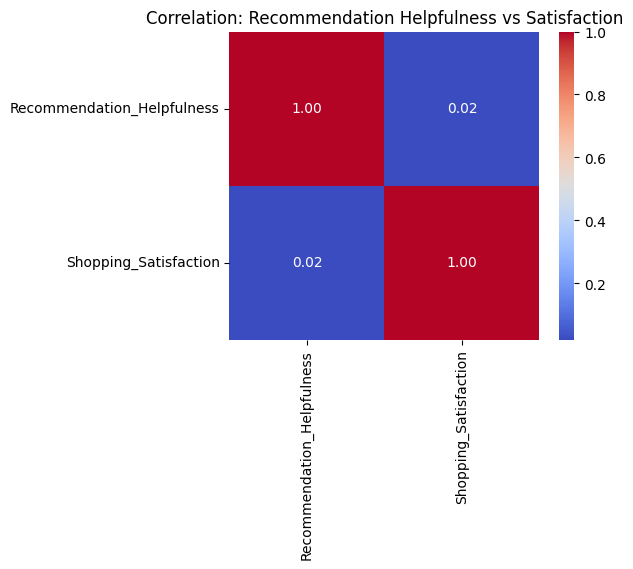

In [297]:
plt.figure(figsize=(5,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation: Recommendation Helpfulness vs Satisfaction")

plt.show()

The correlation heatmap between recommendation helpfulness and shopping satisfaction indicates a very weak relationship between the two variables, with a correlation value close to zero. This suggests that improvements in recommendation helpfulness do not significantly impact overall customer satisfaction. The visual representation further confirms the absence of a strong relationship, highlighting that other factors may play a more important role in influencing customer satisfaction.

## Summarize findings in a clear and visually appealing report format.

PDF attached in ziped filed